# Japan Demographic Decline Analysis

Exploring population changes across Japanese prefectures and cities from 1995 to 2020.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

df_subdiv = pd.read_excel('japan-subdivisions.xlsx')
df_areas = pd.read_excel('japan-prefecture-areas.xlsx')

In [2]:
prefectures = df_subdiv[df_subdiv['Status'] == 'Prefecture'].copy()
cities = df_subdiv[df_subdiv['Status'] == 'City (-shi)'].copy()

for col in ['pop1995', 'pop2000', 'pop2005', 'pop2010', 'pop2015', 'pop2020']:
    prefectures[col] = pd.to_numeric(prefectures[col], errors='coerce')

preferred = ['Aichi', 'Akita', 'Aomori', 'Chiba', 'Ehime', 'Fukui',
             'Fukuoka', 'Fukushima', 'Gifu', 'Gumma', 'Hiroshima',
             'Hokkaido', 'Hyogo', 'Ibaraki', 'Ishikawa', 'Iwate',
             'Kagawa', 'Kagoshima', 'Kanagawa', 'Kochi', 'Kumamoto',
             'Kyoto', 'Mie', 'Miyagi', 'Miyazaki', 'Nagano',
             'Nagasaki', 'Nara', 'Niigata', 'Oita', 'Okayama',
             'Okinawa', 'Osaka', 'Saga', 'Saitama', 'Shiga',
             'Shimane', 'Shizuoka', 'Tochigi', 'Tokushima',
             'Tottori', 'Toyama', 'Wakayama', 'Yamagata',
             'Yamaguchi', 'Yamanashi']

map_rename = {}
for p in preferred:
    hits = prefectures[prefectures['Name'].str.contains(p, case=False, na=False)]
    if not hits.empty:
        map_rename[hits.index[0]] = p

prefectures['Prefecture'] = prefectures.index.map(lambda i: map_rename.get(i, prefectures.loc[i, 'Name']))

areas_clean = df_areas.iloc[1:].copy()
areas_clean['Prefecture'] = areas_clean.iloc[:, 1]
areas_clean['Density'] = pd.to_numeric(areas_clean.iloc[:, 7], errors='coerce')
areas_clean = areas_clean.dropna(subset=['Density'])

print('Prefectures:', len(prefectures))
print('Cities:', len(cities))
print('Density data:', len(areas_clean))

Prefectures: 46
Cities: 792
Density data: 48


## Q(a): Percentage changes in population for prefectures (1995 to 2020)

In [3]:
prefectures['pct_change_95_20'] = (prefectures['pop2020'] / prefectures['pop1995'] - 1) * 100

pct_df = prefectures[['Prefecture', 'pop1995', 'pop2020', 'pct_change_95_20']].sort_values('pct_change_95_20').reset_index(drop=True)

pd.options.display.max_rows = 50
pct_df

,Prefecture,pop1995,pop2020,pct_change_95_20
0,Akita,1213667,959502,-20.941906
1,Aomori,1481663,1237984,-16.446317
2,Kōchi,816704,691527,-15.327095
3,Nagasaki,1544934,1312317,-15.056760
4,Yamagata,1256958,1068027,-15.030812
5,Iwate,1419505,1210534,-14.721399
6,Wakayama,1080435,922584,-14.609949
7,Fukushima,2133592,1833152,-14.081418
8,Yamaguchi,1555543,1342059,-13.724082
9,Tokushima,832427,719559,-13.558907


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#d62728' if p < 0 else '#1f77b4' for p in pct_df['pct_change_95_20']]
ax.barh(pct_df['Prefecture'], pct_df['pct_change_95_20'], color=colors)
ax.set_xlabel('Percentage Change in Population (1995 to 2020)')
ax.set_title('Japan Prefectures: Population Change 1995-2020')
ax.axvline(x=0, color='black', linewidth=0.8)

for i, (pref, val) in enumerate(zip(pct_df['Prefecture'], pct_df['pct_change_95_20'])):
    offset = 0.3 if val >= 0 else -0.55
    sign = '+' if val >= 0 else ''
    ax.text(val + (1 if val >= 0 else -1) * 2000, i + offset, '{}{:.1f}%'.format(sign, val), fontsize=5, va='center')

plt.tight_layout()
plt.savefig('q_a_prefecture_pct_changes.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_849848/2778614724.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


## Q(b): Time series of % population change for each prefecture relative to 1995

ValueError: 'x' has size 6, but 'y1' has an unequal size of 5

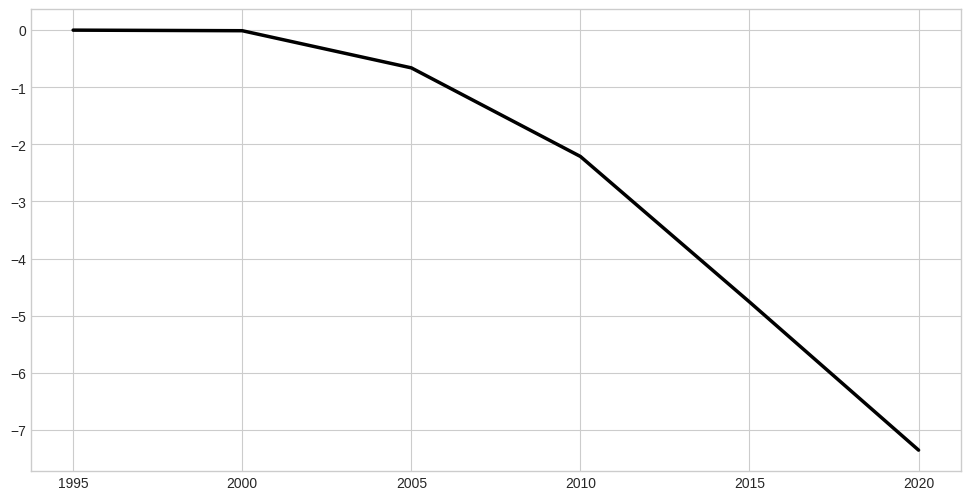

In [5]:
pop_cols = dict(pop1995=1995, pop2000=2000, pop2005=2005,
                pop2010=2010, pop2015=2015, pop2020=2020)

timeseries_data = []
for _, row in prefectures.iterrows():
    base = row['pop1995']
    for col, yr in pop_cols.items():
        pop = row[col]
        if not pd.isna(pop) and base and base > 0:
            pct = (pop / base - 1) * 100
            timeseries_data.append(dict(Prefecture=row['Prefecture'], Year=yr, pct_change=pct))

df_ts = pd.DataFrame(timeseries_data)

fig, ax = plt.subplots(figsize=(12, 6))

median_by_year = df_ts.groupby('Year')['pct_change'].median()
ax.plot(median_by_year.index, median_by_year.values, 'k-', linewidth=2.5, label='Median prefecture')

q25 = df_ts[df_ts['Year'].isin([2000,2005,2010,2015,2020])].groupby('Year')['pct_change'].quantile(0.25).values
q75 = df_ts[df_ts['Year'].isin([2000,2005,2010,2015,2020])].groupby('Year')['pct_change'].quantile(0.75).values
ax.fill_between(median_by_year.index, q25, q75, alpha=0.2, color='gray', label='IQR')

for pref in df_ts['Prefecture'].unique():
    sub = df_ts[df_ts['Prefecture'] == pref].sort_values('Year')
    ax.plot(sub['Year'], sub['pct_change'], alpha=0.05, color='steelblue')

ax.set_xlabel('Year')
ax.set_ylabel('% Change Relative to 1995 Population')
ax.set_title('Population Change for All Prefectures (relative to 1995)')
ax.legend()
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('q_b_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Q(c): Is 1995 population related to % population change (1995 to 2020)?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(prefectures['pop1995'], prefectures['pct_change_95_20'], alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
corr_lin, p_lin = stats.pearsonr(prefectures['pop1995'], prefectures['pct_change_95_20'])
z_lin = np.polyfit(prefectures['pop1995'], prefectures['pct_change_95_20'], 1)
x_lin = np.linspace(prefectures['pop1995'].min(), prefectures['pop1995'].max(), 100)
ax.plot(x_lin, np.poly1d(z_lin)(x_lin), 'r--', alpha=0.7)
ax.set_xlabel('Population in 1995')
ax.set_ylabel('Percentage Change 1995 to 2020')
ax.set_title('Scatter: 1995 Pop vs %% Change\nPearson r = {:.3f}, p = {:.4f}'.format(corr_lin, p_lin))

ax = axes[1]
ax.scatter(np.log10(prefectures['pop1995']), prefectures['pct_change_95_20'], alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
corr_log, p_log = stats.pearsonr(np.log10(prefectures['pop1995']), prefectures['pct_change_95_20'])
z_log = np.polyfit(np.log10(prefectures['pop1995']), prefectures['pct_change_95_20'], 1)
x_log = np.linspace(np.log10(prefectures['pop1995']).min(), np.log10(prefectures['pop1995']).max(), 100)
ax.plot(x_log, np.poly1d(z_log)(x_log), 'r--', alpha=0.7)
ax.set_xlabel('log10(Population in 1995)')
ax.set_ylabel('Percentage Change 1995 to 2020')
ax.set_title('Scatter: log10(1995 Pop) vs %% Change\nPearson r = {:.3f}, p = {:.4f}'.format(corr_log, p_log))

plt.suptitle('1995 Population vs Percentage Population Change (1995-2020)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q_c_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sp = stats.spearmanr(np.log10(prefectures['pop1995']), prefectures['pct_change_95_20'])
print('Statistical Summary')
print('=' * 40)
print('Pearson r (linear):  {:.4f}  (p = {:.6f})'.format(corr_lin, p_lin))
print('Pearson r (log scale): {:.4f}  (p = {:.6f})'.format(corr_log, p_log))
print('Spearman r: {:.4f}  (p = {:.6f})'.format(sp.correlation, sp.pvalue))

growing = prefectures[prefectures['pct_change_95_20'] > 0]
shrinking = prefectures[prefectures['pct_change_95_20'] < 0]
print()
print('Growing prefectures ({}):'.format(len(growing)))
print(growing['Prefecture'].tolist())
print()
print('Mean pop 1995 - growing: {:,}'.format(int(growing['pop1995'].mean())))
print('Mean pop 1995 - shrinking: {:,}'.format(int(shrinking['pop1995'].mean())))

## Q(d): Cities - relation between city size and percentage change

In [ ]:
cities_pct = cities.copy()
cities_pct['pct_change'] = (cities_pct['pop2020'] / cities_pct['pop1995'] - 1) * 100
cities_pct = cities_pct.dropna(subset=['pct_change'])

print('Total cities analyzed: {}'.format(len(cities_pct)))
print('Positive-growth cities: {} / {}'.format((cities_pct['pct_change'] > 0).sum(), len(cities_pct)))
print('Shrinking cities: {} / {}'.format((cities_pct['pct_change'] < 0).sum(), len(cities_pct)))

print()
print('Top 10 growing cities:')
out = cities_pct.nlargest(10, 'pct_change')[['Name', 'pop1995', 'pop2020', 'pct_change']]
print(out.to_string(index=False))
print()
print('Top 10 shrinking cities:')
out2 = cities_pct.nsmallest(10, 'pct_change')[['Name', 'pop1995', 'pop2020', 'pct_change']]
print(out2.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(cities_pct['pop1995'], cities_pct['pct_change'], alpha=0.3, s=20, edgecolors='none')
ax.set_xscale('log')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
corr_c1, p_c1 = stats.pearsonr(cities_pct['pop1995'], cities_pct['pct_change'])
z1 = np.polyfit(np.log10(cities_pct['pop1995']), cities_pct['pct_change'], 1)
x1 = np.logspace(np.log10(cities_pct['pop1995']).min(), np.log10(cities_pct['pop1995']).max(), 100)
ax.plot(x1, np.poly1d(z1)(np.log10(x1)), 'r--', alpha=0.7)
ax.set_xlabel('City Population in 1995 (log scale)')
ax.set_ylabel('Percentage Change 1995 to 2020')
ax.set_title('Cities: Size vs %% Change\nPearson r = {:.4f}'.format(corr_c1))

ax = axes[1]
ax.scatter(np.log10(cities_pct['pop1995']), cities_pct['pct_change'], alpha=0.3, s=20, edgecolors='none')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
corr_c2, p_c2 = stats.pearsonr(np.log10(cities_pct['pop1995']), cities_pct['pct_change'])
z2 = np.polyfit(np.log10(cities_pct['pop1995']), cities_pct['pct_change'], 1)
x2 = np.linspace(np.log10(cities_pct['pop1995']).min(), np.log10(cities_pct['pop1995']).max(), 100)
ax.plot(x2, np.poly1d(z2)(x2), 'r--', alpha=0.7)
ax.set_xlabel('log10(City Population in 1995)')
ax.set_ylabel('Percentage Change 1995 to 2020')
ax.set_title('Cities: log10(Size) vs %% Change\nPearson r = {:.4f}'.format(corr_c2))

plt.suptitle('City Size vs Percentage Population Change (1995-2020)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q_d_city_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sp_city = stats.spearmanr(np.log10(cities_pct['pop1995']), cities_pct['pct_change'])
print('Pearson r: {:.4f}  (p = {:.6f})'.format(corr_c2, p_c2))
print('Spearman r: {:.4f}  (p = {:.6f})'.format(sp_city.correlation, sp_city.pvalue))

cities_pct = cities_pct.assign(pop_bin=pd.qcut(cities_pct['pop1995'], 5, labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large']))
print()
print('Mean %% change by city size group:')
print(cities_pct.groupby('pop_bin')['pct_change'].mean().to_string())

## Q(e): Relation between population density and percentage growth (prefectures)

In [ ]:
pref_density = prefectures[['Prefecture', 'pop1995', 'pop2020', 'pct_change_95_20']].copy()
pref_density = pref_density.merge(areas_clean[['Prefecture', 'Density']], on='Prefecture', how='left')
pref_density = pref_density.dropna(subset=['Density'])

print('Prefectures with density data: {}'.format(len(pref_density)))
pd.set_option('display.max_rows', 100)
print(pref_density[['Prefecture', 'Density', 'pct_change_95_20']].sort_values('Density').to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for i, row in pref_density.iterrows():
    ax.scatter(row['Density'], row['pct_change_95_20'], alpha=0.6, s=50)
    ax.annotate(row['Prefecture'], (row['Density'], row['pct_change_95_20']), fontsize=6,
                xytext=(5, 5), textcoords='offset points')

corr_d1, p_d1 = stats.pearsonr(pref_density['Density'], pref_density['pct_change_95_20'])
zd1 = np.polyfit(pref_density['Density'], pref_density['pct_change_95_20'], 1)
xd1 = np.linspace(pref_density['Density'].min(), pref_density['Density'].max(), 100)
ax.plot(xd1, np.poly1d(zd1)(xd1), 'r--', alpha=0.7)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Population Density (/km2)')
ax.set_ylabel('Percentage Change 1995 to 2020')
ax.set_title('Density vs %% Change (linear)\nPearson r = {:.4f}'.format(corr_d1))

ax = axes[1]
for i, row in pref_density.iterrows():
    ax.scatter(np.log10(row['Density']), row['pct_change_95_20'], alpha=0.6, s=50)
    ax.annotate(row['Prefecture'], (np.log10(row['Density']), row['pct_change_95_20']), fontsize=6,
                xytext=(5, 5), textcoords='offset points')

corr_d2, p_d2 = stats.pearsonr(np.log10(pref_density['Density']), pref_density['pct_change_95_20'])
zd2 = np.polyfit(np.log10(pref_density['Density']), pref_density['pct_change_95_20'], 1)
xd2 = np.linspace(np.log10(pref_density['Density'].min()), np.log10(pref_density['Density'].max()), 100)
ax.plot(xd2, np.poly1d(zd2)(xd2), 'r--', alpha=0.7)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('log10(Population Density (/km2))')
ax.set_ylabel('Percentage Change 1995 to 2020')
ax.set_title('Density vs %% Change (log density)\nPearson r = {:.4f}'.format(corr_d2))

plt.suptitle('Population Density vs Percentage Population Change (1995-2020)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q_e_density_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sp_dens = stats.spearmanr(np.log10(pref_density['Density']), pref_density['pct_change_95_20'])
print('Pearson r (log density): {:.4f}  (p = {:.6f})'.format(corr_d2, p_d2))
print('Spearman r: {:.4f}  (p = {:.6f})'.format(sp_dens.correlation, sp_dens.pvalue))

median_dens = pref_density['Density'].median()
high_density = pref_density[pref_density['Density'] > median_dens]
low_density = pref_density[pref_density['Density'] <= median_dens]
print()
print('Mean %% change for high-density prefectures (>={:,.0f}/km2): {:.2f}%'.format(median_dens, high_density['pct_change_95_20'].mean()))
print('Mean %% change for low-density prefectures (<={:,.0f}/km2): {:.2f}%'.format(median_dens, low_density['pct_change_95_20'].mean()))